# Analys av kundbortfall hos en bank
### Identifiering av riskkunder och rekommendationer
***

## Bakgrund & syfte
### Banken vill minska antalet kunder som lämnar, då det generellt sett är dyrare att skaffa nya kunder än att behålla befintliga.

#### De följande målen finns:
* Identifiera vilka kunder som har högst risk att lämna banken.
* Förstå vilka faktorer som påverkar kundbortfall mest.
* Ge konkreta rekommendationer för att minska kundbortfallet.
***

## Kunddata
### Datasetet innehåller cirka 10 000 bankkunder med följande tillgänlig information.
* Kreditbetyg, ålder, geografisk placering och ålder.
* Antal år som kund.
* Saldo och om kunden har kreditkort.
* Om kunden är aktiv medlem hos banken.
* Uppskattad lön.
* Målvariabler: 1 = har lämnat (Exited), 0 = är befintlig kund.
* NumOfProducts betyder hur många olika bank-produkter/tjänster kunden har hos banken. Exempel: lönekonto, sparkonto, bolån, kreditkort, fonder osv.
***


In [83]:
# Importerar relevanta bibliotek.

import numpy as np
import pandas as pd
pd.options.display.max_columns = 50
pd.options.display.max_rows = 50

from scipy import stats

import matplotlib.pyplot as plt
import seaborn as sns


# Importerar csv filen samt provkör den.
df_bank = pd.read_csv("Customer-Churn-Records.csv")
df_bank

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0,0,1,DIAMOND,300
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0,0,5,PLATINUM,771
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1,1,3,SILVER,564
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1,1,2,GOLD,339


In [84]:
# Undersöker datan för att hitta tidiga eventuella fel.
df_bank.describe().round(2)

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Point Earned
count,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.0,10000.0,10000.00,10000.00
mean,5000.50,15690940.57,650.53,38.92,5.01,76485.89,1.53,0.71,0.52,100090.24,0.2,0.2,3.01,606.52
std,2886.90,71936.19,96.65,10.49,2.89,62397.41,0.58,0.46,0.50,57510.49,0.4,0.4,1.41,225.92
min,1.00,15565701.00,350.00,18.00,0.00,0.00,1.00,0.00,0.00,11.58,0.0,0.0,1.00,119.00
25%,2500.75,15628528.25,584.00,32.00,3.00,0.00,1.00,0.00,0.00,51002.11,0.0,0.0,2.00,410.00
50%,5000.50,15690738.00,652.00,37.00,5.00,97198.54,1.00,1.00,1.00,100193.92,0.0,0.0,3.00,605.00
75%,7500.25,15753233.75,718.00,44.00,7.00,127644.24,2.00,1.00,1.00,149388.25,0.0,0.0,4.00,801.00
max,10000.00,15815690.00,850.00,92.00,10.00,250898.09,4.00,1.00,1.00,199992.48,1.0,1.0,5.00,1000.00


In [85]:
# Undersöker om det finns dubletter.
df_bank[df_bank.duplicated]

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned


In [86]:
# Kollar efter nullvärden.
df_bank.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   RowNumber           10000 non-null  int64  
 1   CustomerId          10000 non-null  int64  
 2   Surname             10000 non-null  str    
 3   CreditScore         10000 non-null  int64  
 4   Geography           10000 non-null  str    
 5   Gender              10000 non-null  str    
 6   Age                 10000 non-null  int64  
 7   Tenure              10000 non-null  int64  
 8   Balance             10000 non-null  float64
 9   NumOfProducts       10000 non-null  int64  
 10  HasCrCard           10000 non-null  int64  
 11  IsActiveMember      10000 non-null  int64  
 12  EstimatedSalary     10000 non-null  float64
 13  Exited              10000 non-null  int64  
 14  Complain            10000 non-null  int64  
 15  Satisfaction Score  10000 non-null  int64  
 16  Card Type       

#### Kommentar av resultat: 

- Vi kan se att det inte finns några null-värden som behövs tas bort. 
- Inga extremvärden.
- Vi har inga dubbletter.
- Värdena ser bra ut för att forsätta i nästa del.

***

## Visualisering och statistik

/var/folders/f3/qwxpslks67bf4y7nqxdn9qpm0000gn/T/ipykernel_17343/105938254.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Exited", data=df_bank, palette="Set2")


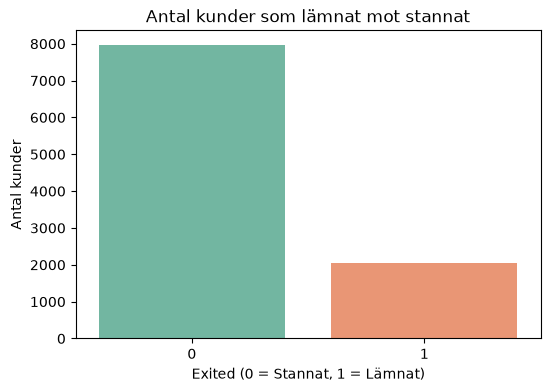

In [110]:
# Diagram för antal kunder som lämnat/stannat.
plt.figure(figsize=(6,4))
sns.countplot(x="Exited", data=df_bank, palette="Set2")
plt.title("Antal kunder som lämnat mot stannat")
plt.xlabel("Exited (0 = Stannat, 1 = Lämnat)")
plt.ylabel("Antal kunder")
plt.show()

In [108]:
# Antal kunder som lämnat/stannat.
print("Totalt antal kunder som lämnat mot stannat:")
print(df_bank["Exited"].value_counts())
print("\nAndel i procent:")
print((df_bank["Exited"].value_counts(normalize=True) * 100).round(1))

Totalt antal kunder som lämnat mot stannat:
Exited
0    7962
1    2038
Name: count, dtype: int64

Andel i procent:
Exited
0    79.6
1    20.4
Name: proportion, dtype: float64


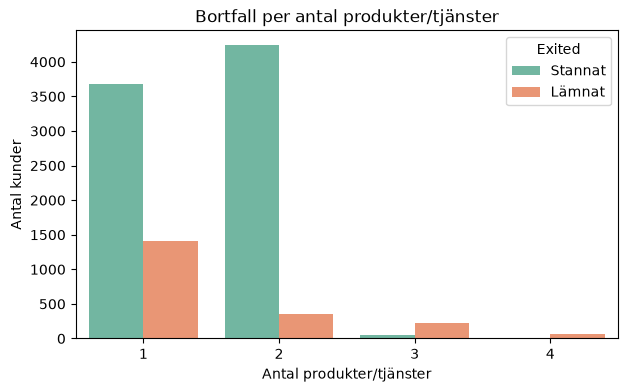

In [106]:
# Diagram för antal tjänster/produkter hos befintliga och förlorade kunder.
plt.figure(figsize=(7,4))
sns.countplot(x="NumOfProducts", hue="Exited", data=df_bank, palette="Set2")
plt.title("Bortfall per antal produkter/tjänster")
plt.xlabel("Antal produkter/tjänster")
plt.ylabel("Antal kunder")
plt.legend(title="Exited", labels=["Stannat", "Lämnat"])
plt.show()

In [105]:
# Antal tjänster/produkter hos befintliga och förlorade kunder.
print("Bortfall-andel per antal produkter/tjänster (%):")
print(pd.crosstab(df_bank["NumOfProducts"], df_bank["Exited"], normalize="index").round(3) * 100)

Bortfall-andel per antal produkter/tjänster (%):
Exited            0      1
NumOfProducts             
1              72.3   27.7
2              92.4    7.6
3              17.3   82.7
4               0.0  100.0


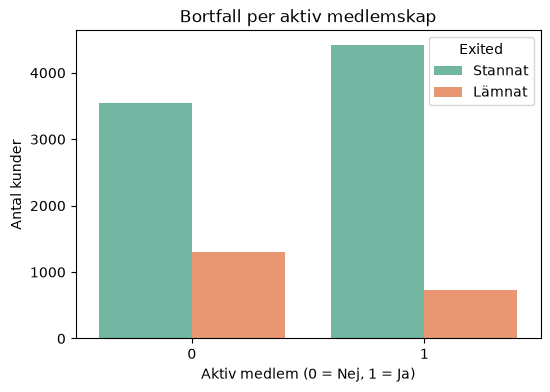

In [103]:
# Diagram på aktiva medlemmar hos befintliga och förlorade kunder.
plt.figure(figsize=(6,4))
sns.countplot(x="IsActiveMember", hue="Exited", data=df_bank, palette="Set2")
plt.title("Bortfall per aktiv medlemskap")
plt.xlabel("Aktiv medlem (0 = Nej, 1 = Ja)")
plt.ylabel("Antal kunder")
plt.legend(title="Exited", labels=["Stannat", "Lämnat"])
plt.show()

In [102]:
# Procentandel av aktiva medlemmar hos befintliga och förlorade kunder.
print("Bortfall-andel per aktiv medlemskap (%):")
print(pd.crosstab(df_bank["IsActiveMember"], df_bank["Exited"], normalize="index").round(3) * 100)

Bortfall-andel per aktiv medlemskap (%):
Exited             0     1
IsActiveMember            
0               73.1  26.9
1               85.7  14.3


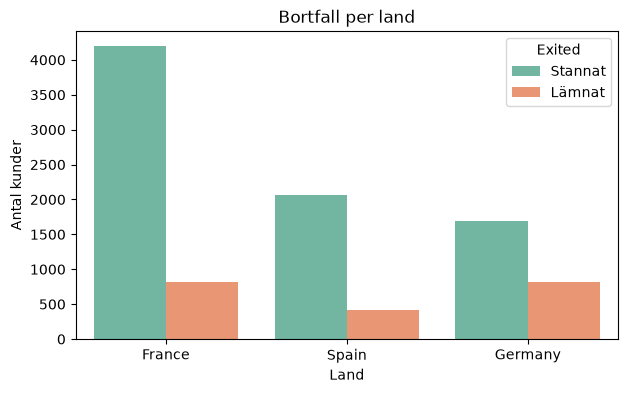

In [101]:
# Diagram på vilka länder befintliga och förlorade kunder tillhör.
plt.figure(figsize=(7,4))
sns.countplot(x="Geography", hue="Exited", data=df_bank, palette="Set2")
plt.title("Bortfall per land")
plt.xlabel("Land")
plt.ylabel("Antal kunder")
plt.legend(title="Exited", labels=["Stannat", "Lämnat"])
plt.show()

In [100]:
# Procentandel i vilka länder befintliga och förlorade kunder tillhör.
print("Bortfall-andel per land (%):")
print(pd.crosstab(df_bank["Geography"], df_bank["Exited"], normalize="index").round(3) * 100)

Bortfall-andel per land (%):
Exited        0     1
Geography            
France     83.8  16.2
Germany    67.6  32.4
Spain      83.3  16.7


/var/folders/f3/qwxpslks67bf4y7nqxdn9qpm0000gn/T/ipykernel_17343/472783234.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Exited", y="Age", data=df_bank, palette="Set2")


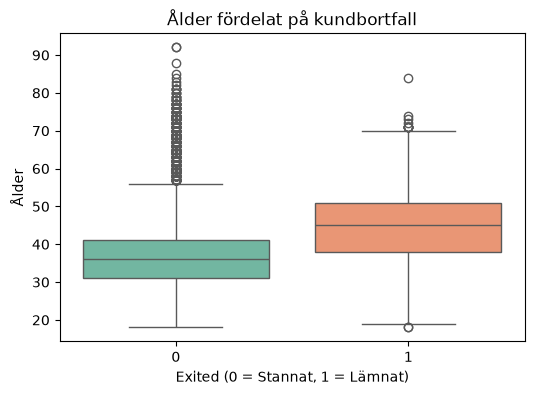

In [99]:
# Diagram på åldersfördelning för befintliga och lämnade kunder.
plt.figure(figsize=(6,4))
sns.boxplot(x="Exited", y="Age", data=df_bank, palette="Set2")
plt.title("Ålder fördelat på kundbortfall")
plt.xlabel("Exited (0 = Stannat, 1 = Lämnat)")
plt.ylabel("Ålder")
plt.show()

/var/folders/f3/qwxpslks67bf4y7nqxdn9qpm0000gn/T/ipykernel_17343/4077070560.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Exited", y="Balance", data=df_bank, palette="Set2")


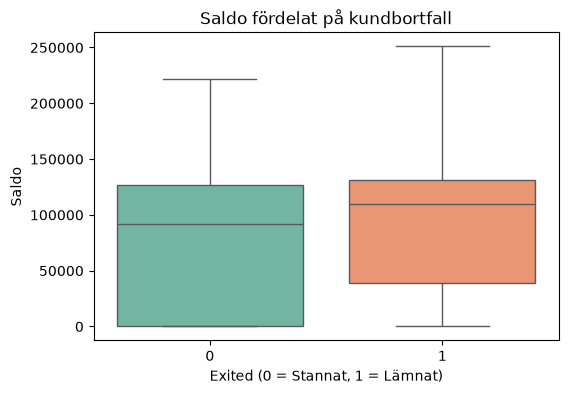

In [98]:
# Diagram på saldo hos befintliga och lämnade kunder.
plt.figure(figsize=(6,4))
sns.boxplot(x="Exited", y="Balance", data=df_bank, palette="Set2")
plt.title("Saldo fördelat på kundbortfall")
plt.xlabel("Exited (0 = Stannat, 1 = Lämnat)")
plt.ylabel("Saldo")
plt.show()

In [97]:
# Medelvärde för Ålder och Saldo
print("Medelvärde för Ålder och Saldo (churn vs icke-churn):")
print(df_bank.groupby("Exited")[["Age", "Balance"]].mean().round(1))

Medelvärde för Ålder och Saldo (churn vs icke-churn):
         Age  Balance
Exited               
0       37.4  72742.8
1       44.8  91109.5


## Insikter

* Totalt har cirka **20 %** av kunderna lämnat banken.
* Den starkaste riskfaktorn är **antal produkter**. Kunder med endast 1 produkt lämnar i betydligt högre utsträckning än kunder med 2 produkter.
* **Inaktiva medlemmar** har markant högre risk att lämna jämfört med aktiva medlemmar.
* **Tyskland** har högst kundbortfall av de tre länderna.
* Kunder som lämnar är i genomsnitt **äldre** (ca 45 år jämfört med 37 år) och har **högre saldo** (ca 91 000 jämfört med 73 000).
* Kombinationen av hög ålder, högt saldo och få produkter utgör en tydlig riskgrupp.

## Rekommendationer

Baserat på analysen rekommenderas följande prioriterade åtgärder för att minska kundbortfallet:

1. **Prioritera kunder med endast 1 produkt**  
   Denna grupp har den högsta risken att lämna. Banken bör aktivt arbeta med merförsäljning (t.ex. sparkonto, kreditkort eller andra tjänster) för att öka kundens engagemang och bindning.

2. **Aktivera inaktiva medlemmar**  
   Inaktiva kunder lämnar i betydligt högre grad. Inför riktade kampanjer, personliga erbjudanden eller automatiserade påminnelser för att öka aktiviteten och kvarhållningen.

3. **Särskild uppföljning av äldre kunder med högt saldo**  
   Dessa kunder är både mer benägna att lämna och har högre ekonomiskt värde. Ge dem personlig kontakt och skräddarsydda erbjudanden för att minska risken att de byter bank.

4. **Undersök den tyska marknaden närmare**  
   Eftersom Tyskland har högst kundbortfall bör banken analysera lokala orsaker, exempelvis konkurrenssituation, prissättning eller kundservice, och vidta riktade åtgärder.

5. **Skapa en risklista för proaktiv bearbetning**  
   Kombinera de starkaste riskfaktorerna (få produkter + inaktiv + högre ålder) och låt sälj- eller kundtjänstteam arbeta proaktivt med dessa kunder.

## Slutsats

Analysen visar att kundbortfallet inte är slumpmässigt utan påverkas av tydliga faktorer, framför allt antal produkter, aktivitetsnivå, ålder och geografisk placering. Genom att fokusera på de identifierade riskgrupperna, särskilt kunder med endast en produkt, inaktiva medlemmar samt äldre kunder med högt saldo, kan banken arbeta mer riktat för att minska kundbortfallet och behålla mer värde i kundbasen.